In [ ]:
## 5.4.1 1. Implement temperature scaling for your pedestrian detector. Evaluate accuracy at T ∈{0.5, 1.0, 2.0}using a fixed decision threshold of 0.5 on pT . Report your results.
# How does accuracy change across temperatures, and why?

from pathlib import Path
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.metrics import accuracy_score
from tqdm import tqdm

# check if test and pedistrian folder properly exist
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

TEST_DIR = PROJECT_ROOT / "data" / "exercise_3_6" / "test"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

PEDESTRIAN_MODEL_PATH = MODELS_DIR / "has_pedestrian_resnet18.pt"

print("Test folder exists:", TEST_DIR.exists())
print("Pedestrian model exists:", PEDESTRIAN_MODEL_PATH.exists())

Test folder exists: True
Pedestrian model exists: True


In [13]:
# load test labels
test_csv = sorted(TEST_DIR.rglob("*.csv"))[0]
test_df = pd.read_csv(test_csv)

print("Test shape:", test_df.shape)
print("Columns:", test_df.columns.tolist())

display(test_df.head())

Test shape: (3600, 7)
Columns: ['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle']


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,False,15,0,35
1,10,True,False,True,299,0,116
2,20,True,False,True,298,0,307
3,30,True,False,True,297,0,258
4,40,True,False,True,297,0,249


In [14]:
# image mapping
IMAGE_EXTENSIONS = ["*.png", "*.jpg", "*.jpeg"]

def find_images(folder):
    image_files = []
    for ext in IMAGE_EXTENSIONS:
        image_files.extend(folder.rglob(ext))
    return image_files

def build_frame_to_image_map(folder):
    image_files = find_images(folder)
    frame_to_image = {}

    for image_path in image_files:
        number = "".join([c for c in image_path.stem if c.isdigit()])
        if number != "":
            frame_to_image[int(number)] = image_path

    return frame_to_image

test_frame_to_image = build_frame_to_image_map(TEST_DIR)

print("Mapped test images:", len(test_frame_to_image))
print("First 5 frames:", list(test_frame_to_image.keys())[:5])

Mapped test images: 3600
First 5 frames: [31600, 35300, 27710, 23210, 26340]


In [16]:
# creating a class for dataset and image transform
class CarlaBinaryDataset(Dataset):
    def __init__(self, dataframe, frame_to_image, label_column, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.frame_to_image = frame_to_image
        self.label_column = label_column
        self.transform = transform

        self.df = self.df[
            self.df["frame"].astype(int).isin(frame_to_image.keys())
        ].reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        frame = int(row["frame"])

        image_path = self.frame_to_image[frame]
        image = Image.open(image_path).convert("RGB")

        label = torch.tensor(float(row[self.label_column]), dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label
    
image_transform = transforms.Compose([
transforms.Resize((224, 224)),
transforms.ToTensor()
])
    
# recreating pedestrian model
def create_model():
    model = models.resnet18(weights=None)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 1)
    return model    

In [17]:
# evaluating the pedestrian model with tempreture scaling
def evaluate_temperature(T, batch_size=32):
    label_column = "has_pedestrian"

    dataset = CarlaBinaryDataset(
        test_df,
        test_frame_to_image,
        label_column,
        transform=image_transform
    )

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    print(f"Evaluating T={T} on device: {device}")

    model = create_model().to(device)
    model.load_state_dict(torch.load(PEDESTRIAN_MODEL_PATH, map_location=device))
    model.eval()

    all_true = []
    all_pred = []

    with torch.no_grad():
        for images, labels in tqdm(loader):
            images = images.to(device)

            logits = model(images).squeeze(1)

            # Temperature scaling
            scaled_logits = logits / T

            # Sigmoid activation after temperature scaling
            probabilities = torch.sigmoid(scaled_logits)

            # Fixed threshold 0.5
            predictions = (probabilities >= 0.5).int().cpu().numpy()

            labels = labels.int().cpu().numpy()

            all_pred.extend(predictions)
            all_true.extend(labels)

    accuracy = accuracy_score(all_true, all_pred)

    return {
        "temperature": T,
        "accuracy": round(accuracy, 4)
    }

# evaluating accuracy at T = 0.5, 1.0, 2.0
temperatures = [0.5, 1.0, 2.0]

temperature_results = []

for T in temperatures:
    result = evaluate_temperature(T)
    temperature_results.append(result)

temperature_results_df = pd.DataFrame(temperature_results)

display(temperature_results_df)

Evaluating T=0.5 on device: mps


100%|██████████| 113/113 [00:17<00:00,  6.61it/s]


Evaluating T=1.0 on device: mps


100%|██████████| 113/113 [00:16<00:00,  6.71it/s]


Evaluating T=2.0 on device: mps


100%|██████████| 113/113 [00:16<00:00,  6.80it/s]


,temperature,accuracy
0,0.5,0.8206
1,1.0,0.8206
2,2.0,0.8206


In [ ]:
# saving above results
RESULTS_DIR.mkdir(exist_ok=True)

results_path = RESULTS_DIR / "exercise_5_4_1_temperature_scaling_accuracy.csv"
temperature_results_df.to_csv(results_path, index=False)

print("Saved results to:", results_path)

Saved results to: /Users/niveditakowlagi/Documents/DKE/SoSe 2026/Intro to ML/ML_Safety_Exercise3/results/exercise_5_4_1_temperature_scaling_accuracy.csv


Based on above results, the accuracy did not change across the three temperatures, because the decision threshold was fixed at 0.5. For a binary classifier, sigmoid(z/T) is above 0.5 whenever z is above 0, as long as T > 0. Therefore, changing T changes the confidence values but usually does not change the final class prediction at threshold 0.5.

A lower temperature makes probabilities more closer to 0 or 1. A higher temperature makes probabilities closer to 0.5. Hence, tempreture changes the sharpeness of probability distributoin.

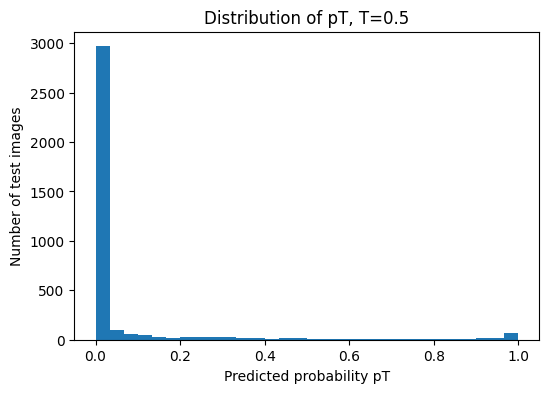

Saved: /Users/niveditakowlagi/Documents/DKE/SoSe 2026/Intro to ML/ML_Safety_Exercise3/results/exercise_5_4_2_pT_distribution_T_0.5.png


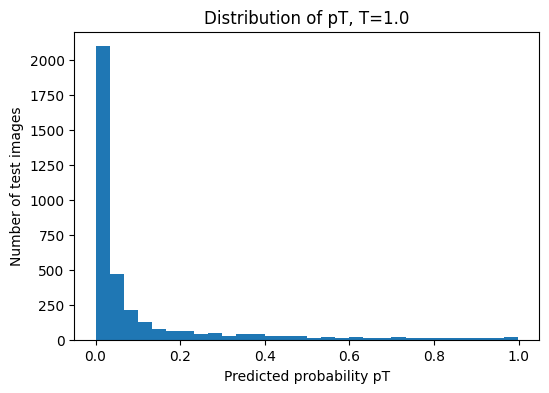

Saved: /Users/niveditakowlagi/Documents/DKE/SoSe 2026/Intro to ML/ML_Safety_Exercise3/results/exercise_5_4_2_pT_distribution_T_1.0.png


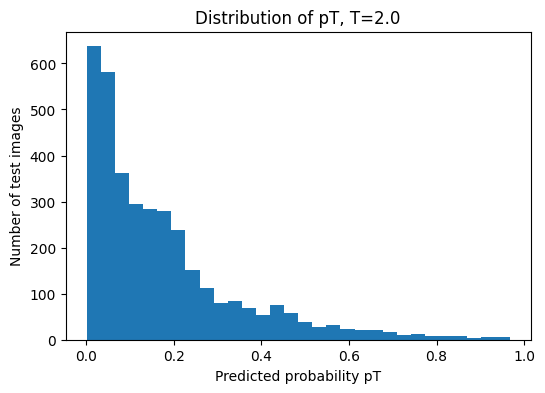

Saved: /Users/niveditakowlagi/Documents/DKE/SoSe 2026/Intro to ML/ML_Safety_Exercise3/results/exercise_5_4_2_pT_distribution_T_2.0.png


In [20]:
# 5.4.2. Plot the distribution of pT over your test set for each temperature. Describe qualitatively how the shape changes.

import matplotlib.pyplot as plt

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

dataset = CarlaBinaryDataset(
    test_df,
    test_frame_to_image,
    "has_pedestrian",
    transform=image_transform
)

loader = DataLoader(dataset, batch_size=32, shuffle=False)

model = create_model().to(device)
model.load_state_dict(torch.load(PEDESTRIAN_MODEL_PATH, map_location=device))
model.eval()

temperatures = [0.5, 1.0, 2.0]

for T in temperatures:
    probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            logits = model(images).squeeze(1)
            pT = torch.sigmoid(logits / T)
            probs.extend(pT.cpu().numpy())

    plt.figure(figsize=(6, 4))
    plt.hist(probs, bins=30)
    plt.title(f"Distribution of pT, T={T}")
    plt.xlabel("Predicted probability pT")
    plt.ylabel("Number of test images")
    save_path = RESULTS_DIR / f"exercise_5_4_2_pT_distribution_T_{T}.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", save_path)

For T = 0.5, the probabilities become sharper and move closer to 0 or 1. This means the model appears more confident.
For T = 1.0, the distribution shows the original model output without temperature scaling.
For T = 2.0, the probabilities become softer and move closer to 0.5. This means the model appears less confident.

Overall, lower temperature makes the output probabilities more extreme, while higher temperature makes them less extreme. 
This changes the confidence distribution, even if the final accuracy with threshold 0.5 may stay the same.

In [22]:
## 5.4.3. Recall the example safety constraint: “If model confidence is below threshold θ, reduce speed to ≤15 km/h.” Suppose θ = 0.6. How does T affect whether the constraint
# triggers in practice? Which temperature leads to less safe system behaviour, and why?

# to check how often the constraint triggers

theta = 0.6
temperatures = [0.5, 1.0, 2.0]

for T in temperatures:
    probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            logits = model(images).squeeze(1)
            pT = torch.sigmoid(logits / T)
            probs.extend(pT.cpu().numpy())

    # Confidence of binary classifier = confidence in predicted class
    confidences = [max(p, 1 - p) for p in probs]

    trigger_rate = sum(conf < theta for conf in confidences) / len(confidences)

    print(f"T={T}: speed reduction triggers for {trigger_rate:.2%} of test images")

T=0.5: speed reduction triggers for 1.67% of test images
T=1.0: speed reduction triggers for 3.61% of test images
T=2.0: speed reduction triggers for 7.56% of test images


As seen above, as T increases, the safety constraint triggers more often. According to my results above, the trigger rate increased from 1.67% at T = 0.5 to 3.61% at T = 1.0 and 7.56% at T = 2.0.

This happens because low T makes probabilities sharper and more confident, while high T makes probabilities softer and closer to 
0.5. Therefore, at higher T, more predictions fall below the confidence threshold θ = 0.6.

The less safe setting is T = 0.5 because it makes the model overconfident and triggers the speed-reduction rule least often. 
If the model is wrong but confident, the system may fail to slow down. T = 2.0 is more safe option because it triggers speed reduction more often.

5.4.4 Is measuring accuracy sufficient to verify this constraint. What additional property of the model output must be measured?
# Ans:
No, accuracy is not sufficient. The constraint depends on confidence, not only correct predictions. Therefore, we must measure whether the model probabilities are calibrated. If the model is overconfident, it may be wrong but still above θ = 0.6, so the speed-reduction rule will not trigger. Additional properties to measure are calibration, confidence distribution, threshold trigger rate, and overconfident errors.